In [1]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser
from pydantic import BaseModel,Field

from typing import TypedDict,Annotated,Counter,List

from langgraph.graph import StateGraph,START,END
import operator


d:\GenAI\2.LangGraph\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


# 2. Parallel or Orchestrator Workflow

## 1. In this user will provide a Essay the workflow will count words, characters, and lines in the essay

In [3]:
class CounterState(TypedDict):
    essay:str
    word_count:int
    char_count:int
    lines_count:int
    summary:str
    
    
counter_graph=StateGraph(state_schema=CounterState)
    

In [4]:
def word_counter(state:CounterState):
    essay=state['essay']
    s=essay.split()
    word_count=len(s)
    return {'word_count':word_count}    
    
    


def char_counter(state: CounterState):
    essay=state['essay']
    char_count=len(essay)
    return {'char_count':char_count}


    
def lines_counter(state: CounterState):
    essay=state['essay']
    s=essay.split('\n')
    lines_count=len(s)
    return {'lines_count':lines_count} 

def summary(state: CounterState):
    summary=f'''
    Total Number of Words: {state['word_count']}
    Total Number of Characters: {state['char_count']}
    Total Number of line: {state['lines_count']}
    
    '''
    
    return {'summary':summary}


In [5]:
counter_graph.add_node("word_counter",word_counter)
counter_graph.add_node("char_counter",char_counter)
counter_graph.add_node("lines_counter",lines_counter)
counter_graph.add_node("summary",summary)


counter_graph.add_edge(start_key=START,end_key='word_counter')
counter_graph.add_edge(start_key=START,end_key='char_counter')
counter_graph.add_edge(start_key=START,end_key='lines_counter')

counter_graph.add_edge(start_key='word_counter',end_key='summary')
counter_graph.add_edge(start_key='char_counter',end_key='summary')
counter_graph.add_edge(start_key='lines_counter',end_key='summary')


counter_graph.add_edge(start_key='summary',end_key=END)



workflow=counter_graph.compile()

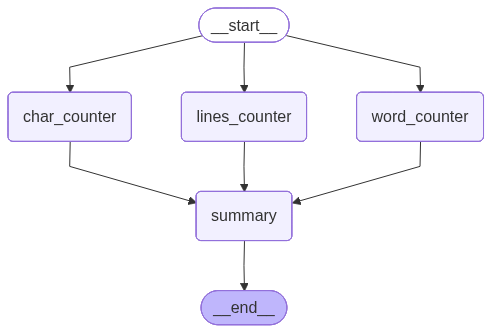

In [6]:
workflow

In [7]:
essay='''

Generative AI has emerged as one of the most transformative technologies of the 21st century. Unlike traditional artificial intelligence systems that focus primarily on analyzing data and making predictions, generative AI has the remarkable ability to create new content. From writing human-like text and generating realistic images to composing music and assisting in software development, generative AI is redefining the boundaries of creativity and productivity.

At its core, generative AI is powered by advanced machine learning models trained on vast amounts of data. These models learn patterns, structures, and relationships within the data, enabling them to produce outputs that closely resemble human-created content. Technologies such as large language models and diffusion models have played a crucial role in this evolution, making AI systems more versatile and capable than ever before.

One of the most significant impacts of generative AI can be seen in the field of content creation. Writers, designers, and developers are increasingly using AI tools to enhance their workflows. For instance, a writer can generate ideas or drafts in seconds, while a designer can create visuals with minimal effort. In software development, generative AI can assist in writing code, debugging errors, and even building entire applications. This not only increases efficiency but also lowers the barrier to entry for individuals who may not have advanced technical skills.

In addition to creative industries, generative AI is making strides in healthcare, education, and business. In healthcare, it can help generate medical reports, assist in drug discovery, and simulate biological processes. In education, it enables personalized learning experiences by adapting content to individual student needs. Businesses are leveraging generative AI for customer support, marketing, and data analysis, leading to improved decision-making and enhanced customer experiences.

However, the rise of generative AI also brings several challenges and ethical concerns. One major issue is the potential for misuse, such as generating deepfakes or spreading misinformation. There are also concerns about data privacy, as these models are often trained on large datasets that may include sensitive information. Additionally, the increasing reliance on AI-generated content raises questions about originality, intellectual property, and the future of human creativity.

Another important consideration is the impact on employment. While generative AI can automate repetitive tasks and increase productivity, it may also disrupt certain job roles. However, it is important to view this transformation as an opportunity rather than a threat. As history has shown, technological advancements often lead to the creation of new roles and industries. The key lies in adapting to change and acquiring new skills that complement AI technologies.

Looking ahead, the future of generative AI is both exciting and uncertain. As the technology continues to evolve, it is likely to become more integrated into our daily lives. We may see AI systems that can collaborate with humans more effectively, understand context more deeply, and produce even more sophisticated outputs. At the same time, it is essential to establish clear regulations and ethical guidelines to ensure that generative AI is used responsibly and for the benefit of society.

In conclusion, generative AI represents a significant leap forward in the field of artificial intelligence. Its ability to create, innovate, and assist across various domains makes it a powerful tool for the future. While challenges and risks exist, with careful management and ethical considerations, generative AI has the potential to enhance human capabilities and drive progress in unprecedented ways.



'''

In [8]:
response=workflow.invoke({'essay':essay})

In [9]:
response

{'essay': '\n\nGenerative AI has emerged as one of the most transformative technologies of the 21st century. Unlike traditional artificial intelligence systems that focus primarily on analyzing data and making predictions, generative AI has the remarkable ability to create new content. From writing human-like text and generating realistic images to composing music and assisting in software development, generative AI is redefining the boundaries of creativity and productivity.\n\nAt its core, generative AI is powered by advanced machine learning models trained on vast amounts of data. These models learn patterns, structures, and relationships within the data, enabling them to produce outputs that closely resemble human-created content. Technologies such as large language models and diffusion models have played a crucial role in this evolution, making AI systems more versatile and capable than ever before.\n\nOne of the most significant impacts of generative AI can be seen in the field o

## UPSC Essay Reviewer
In this User will Provide a Essay the LLM model will evaluate the essay based on some criteria and also provide feedback and individual score and final feedback and final score

In [18]:
# creating model with structured output

# Structure

class Structure(BaseModel):
    feedback:str=Field(description='Provide a Clean and strong feedback for the users input')
    rating:int=Field(gt=0,le=10,description='Rate the Users input for the range for 0 to 10')

model=ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')
model=model.with_structured_output(schema=Structure)

In [26]:
essay='''
Technology is very imporant in todays world and it have changed the way people live there lifes. Many peoples are using smartphones, computers and internet for doing many things like study, work and entertainment. But sometime technology also create problems which we dont notice very easily.

First of all, technology make communication more easy but also more complicated. Peoples are talking more online but they dont meet face to face which reduce real human connection. For example, many childrens spend lot of time on social medias instead of playing outside or talking with family members.

Another problem is that technology cause distraction. Students are trying to study but they checking phones again and again. This reduce there concentration and effect there performance in exams. Also, too much screen time is not good for health and it can cause eye problems and stress.

On the other hand, technology also gives many benefits. It helps in education by providing online resources and courses. Peoples can learn new skills from anywhere in the world. But the problem is not technology itself, it is how we use it.

In conclusion, technology is both good and bad. We should use it carefully and dont become depend on it too much. If we use technology in a proper way, it can improve our life but if not it can also harm us.

'''

In [20]:
class Evaluator(TypedDict):
    essay:str
    language_feedback:str
    grammar_feedback:str
    spellings_feedback:str
    individual_rating:Annotated[List[int],operator.add]
    overall_rating:int
    overall_feedback:str
    
    
graph=StateGraph(state_schema=Evaluator)

In [21]:
parser=StrOutputParser()

In [22]:
def language_evaluator(state:Evaluator):
    essay=state['essay']
    
    prompt=PromptTemplate(
        template='''
        You are a language quality evaluator.

        Evaluate the given essay based on:
        - Clarity of expression
        - Sentence structure
        - Flow and readability
        - Vocabulary usage

        Essay:
        {essay}

        
        ''',
        input_variables=['essay']
    )
    chain=prompt | model 
    
    response=chain.invoke({'essay':essay})
    
    return {'language_feedback':response.feedback,'individual_rating':[response.rating]}

def grammar_evaluator(state: Evaluator):
    essay=state['essay']
    
    prompt=PromptTemplate(
        template='''
        You are a grammar evaluator.

        Analyze the essay for:
        - Grammar mistakes
        - Incorrect sentence formation
        - Tense consistency
        - Subject-verb agreement

        Essay:
        {essay}

        
        
        ''',
        input_variables=['essay']
    )
    chain=prompt | model 
    
    response=chain.invoke({'essay':essay})
    
    return {'grammar_feedback':response.feedback,'individual_rating':[response.rating]}



def spellings_evaluator(state: Evaluator):
    essay=state['essay']
    
    prompt=PromptTemplate(
        template='''
        You are a spelling evaluator.

        Check the essay for:
        - Spelling mistakes
        - Typographical errors
        - Incorrect word usage

        Essay:
        {essay}
        
        
        
        ''',
        input_variables=['essay']
    )
    chain=prompt | model 
    
    response=chain.invoke({'essay':essay})
    
    return {'spellings_feedback':response.feedback,'individual_rating':[response.rating]}




def overall_evaluator(state: Evaluator):
    essay=state['essay']
    
    prompt=PromptTemplate(
        template='''
        You are an overall essay evaluator.

        Evaluate the essay holistically based on:
        - Language quality
        - Grammar
        - Spelling
        - Overall coherence

        Essay:
        {essay}
        
        ''',
        input_variables=['essay']
    )
    chain=prompt | model 
    
    response=chain.invoke({'essay':essay})
    
    return {'language_feedback':response.feedback,'overall_rating':response.rating}

In [23]:
graph.add_node('language_evaluator',language_evaluator)
graph.add_node("grammar_evaluator",grammar_evaluator)
graph.add_node('spellings_evaluator',spellings_evaluator)
graph.add_node('overall_evaluator',overall_evaluator)

graph.add_edge(start_key=START,end_key='language_evaluator')
graph.add_edge(start_key=START,end_key='grammar_evaluator')
graph.add_edge(start_key=START,end_key='spellings_evaluator')

graph.add_edge(start_key='language_evaluator',end_key='overall_evaluator')
graph.add_edge(start_key='grammar_evaluator',end_key='overall_evaluator')
graph.add_edge(start_key='spellings_evaluator',end_key='overall_evaluator')

graph.add_edge(start_key='overall_evaluator',end_key=END)


workflow=graph.compile()


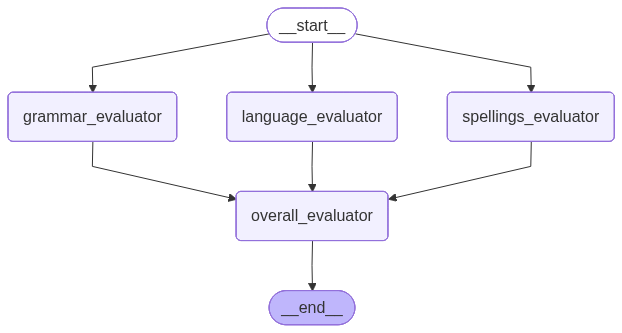

In [24]:
workflow

In [27]:
workflow.invoke({'essay':essay})

{'essay': '\nTechnology is very imporant in todays world and it have changed the way people live there lifes. Many peoples are using smartphones, computers and internet for doing many things like study, work and entertainment. But sometime technology also create problems which we dont notice very easily.\n\nFirst of all, technology make communication more easy but also more complicated. Peoples are talking more online but they dont meet face to face which reduce real human connection. For example, many childrens spend lot of time on social medias instead of playing outside or talking with family members.\n\nAnother problem is that technology cause distraction. Students are trying to study but they checking phones again and again. This reduce there concentration and effect there performance in exams. Also, too much screen time is not good for health and it can cause eye problems and stress.\n\nOn the other hand, technology also gives many benefits. It helps in education by providing onl